# MVP: Predicting Post-Graduation Earnings from College Characteristics

Julia Lu, Rhea Chellani, DATA 402/403

Using College Scorecard data to predict median earnings 10 years after enrollment from college characteristics like tuition, graduation rate, and admission rate. Models: linear regression, ridge, lasso.


## 0. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## 1. Dataset and Preprocessing

Using Most-Recent-Cohorts-Institution.csv, one row per school with the most recent data available. The scorecard uses 'PrivacySuppressed' when a cell is suppressed for privacy and 'NULL' when data wasn't reported. We replace both with NaN and load everything as strings first to avoid pandas type issues.


In [2]:
DATA_PATH = 'College_Scorecard_Raw_Data_03232026/Most-Recent-Cohorts-Institution.csv'

df_raw = pd.read_csv(DATA_PATH, dtype=str, low_memory=False)
df_raw = df_raw.replace('PrivacySuppressed', np.nan)
df_raw = df_raw.replace('NULL', np.nan)

print("Shape: " + str(df_raw.shape))
print("Columns: " + str(df_raw.shape[1]))


Shape: (6322, 3308)
Columns: 3308


## 2. Feature Selection

The dataset has ~3000 columns so we picked 10 that seemed most relevant:

- ADM_RATE: admission rate
- SAT_AVG: average SAT score
- TUITIONFEE_IN / TUITIONFEE_OUT: tuition (in and out of state)
- UGDS: total undergrad enrollment
- C150_4: 4-year graduation rate
- PCTPELL: % of students on Pell grants (low income indicator)
- PCTFLOAN: % of students with federal loans
- CONTROL: school type (1=public, 2=private nonprofit, 3=for-profit)
- LOCALE: how urban/rural the school is

Target: MD_EARN_WNE_P10, median earnings 10 years after first enrolling


In [3]:
FEATURES = [
    'ADM_RATE',
    'SAT_AVG',
    'TUITIONFEE_IN',
    'TUITIONFEE_OUT',
    'UGDS',
    'C150_4',
    'PCTPELL',
    'PCTFLOAN',
    'CONTROL',
    'LOCALE',
]
TARGET = 'MD_EARN_WNE_P10'
ID_COLS = ['INSTNM', 'STABBR']


In [4]:
cols = ID_COLS + FEATURES + [TARGET]
df = df_raw[cols].copy()

for col in FEATURES + [TARGET]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)
print("")
print("Rows before dropping: " + str(len(df)))


INSTNM              object
STABBR              object
ADM_RATE           float64
SAT_AVG            float64
TUITIONFEE_IN      float64
TUITIONFEE_OUT     float64
UGDS               float64
C150_4             float64
PCTPELL            float64
PCTFLOAN           float64
CONTROL              int64
LOCALE             float64
MD_EARN_WNE_P10    float64
dtype: object

Rows before dropping: 6322


## 3. EDA


In [5]:
missing = df[FEATURES + [TARGET]].isnull().mean()
missing = missing.sort_values(ascending=False)

print("Missing value rates:")
for col in missing.index:
    val = round(missing[col] * 100, 1)
    print(col + ": " + str(val) + "%")


Missing value rates:
SAT_AVG: 83.6%
ADM_RATE: 69.5%
C150_4: 63.9%
TUITIONFEE_IN: 42.1%
TUITIONFEE_OUT: 42.1%
MD_EARN_WNE_P10: 18.2%
PCTPELL: 12.3%
PCTFLOAN: 12.3%
UGDS: 11.6%
LOCALE: 7.5%
CONTROL: 0.0%


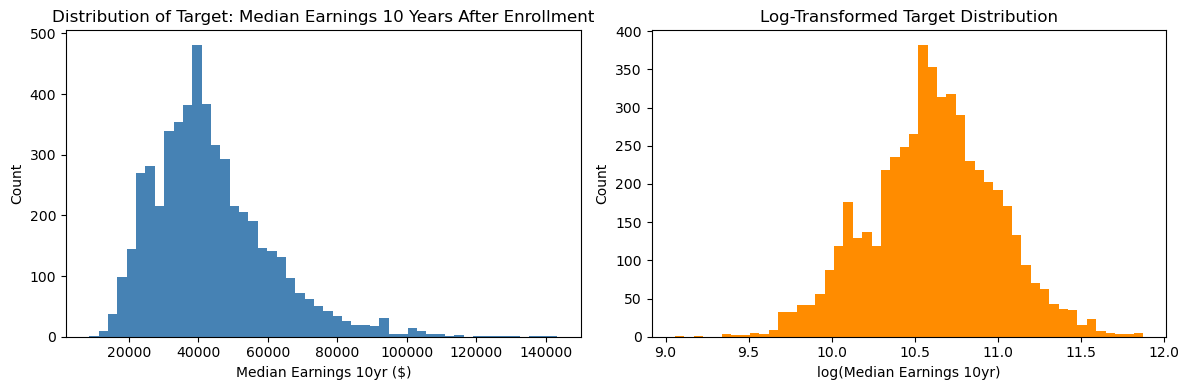

In [6]:
target_vals = df[TARGET].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_vals.plot(kind='hist', bins=50, ax=axes[0], color='steelblue')
axes[0].set_xlabel('Median Earnings 10yr ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Target: Median Earnings 10 Years After Enrollment')

log_target = np.log1p(target_vals)
log_target.plot(kind='hist', bins=50, ax=axes[1], color='darkorange')
axes[1].set_xlabel('log(Median Earnings 10yr)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-Transformed Target Distribution')

plt.tight_layout()
plt.savefig('figures/fig_target_distribution.png', bbox_inches='tight')
plt.show()


In [7]:
df[FEATURES + [TARGET]].describe().round(2)


,ADM_RATE,SAT_AVG,TUITIONFEE_IN,TUITIONFEE_OUT,UGDS,C150_4,PCTPELL,PCTFLOAN,CONTROL,LOCALE,MD_EARN_WNE_P10
count,1927.00,1038.00,3662.00,3662.00,5587.00,2283.00,5547.00,5547.00,6322.00,5851.00,5173.0
mean,0.73,1184.39,17753.96,21231.10,2592.51,0.52,0.43,0.40,2.05,19.94,43700.3
std,0.23,148.47,16350.64,15353.46,6472.21,0.22,0.22,0.27,0.83,9.85,17142.6
min,0.00,720.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,-3.00,8579.0
25%,0.61,1084.50,5792.50,9935.00,120.00,0.38,0.27,0.14,1.00,12.00,31914.0
50%,0.78,1161.00,11943.50,16364.00,540.00,0.52,0.40,0.43,2.00,21.00,40747.0
75%,0.91,1270.75,23760.00,28535.00,2163.00,0.67,0.59,0.62,3.00,22.00,52341.0
max,1.00,1560.00,72097.00,72097.00,163164.00,1.00,1.00,1.00,3.00,43.00,143372.0


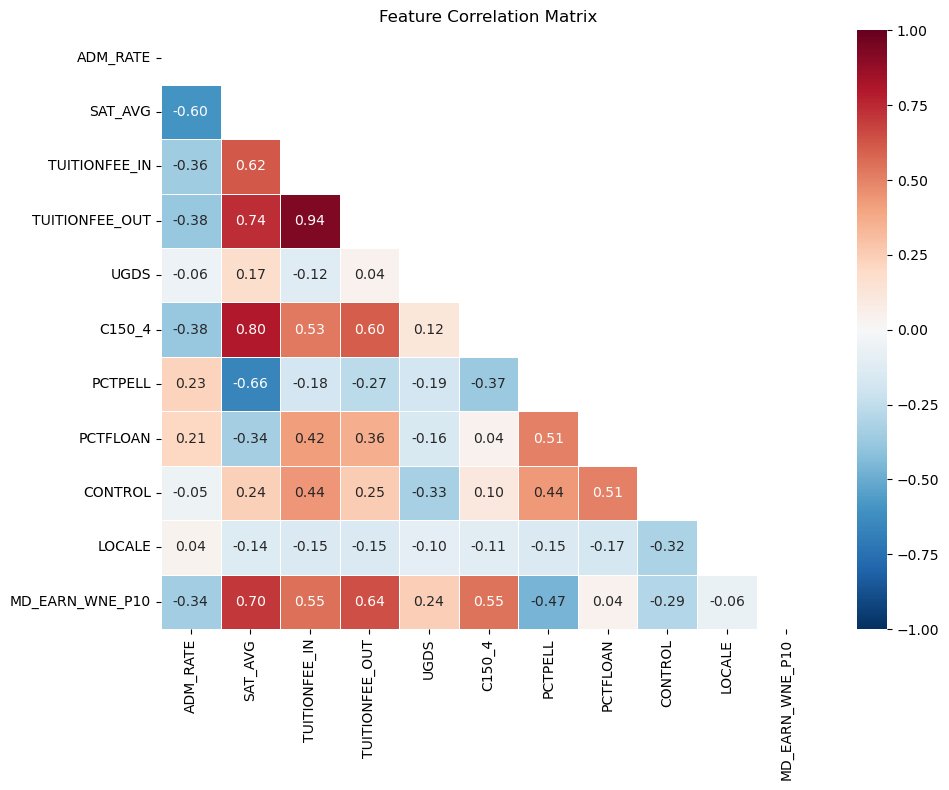

In [8]:
corr_data = df[FEATURES + [TARGET]].corr()
mask = np.triu(np.ones_like(corr_data, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_data, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('figures/fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()


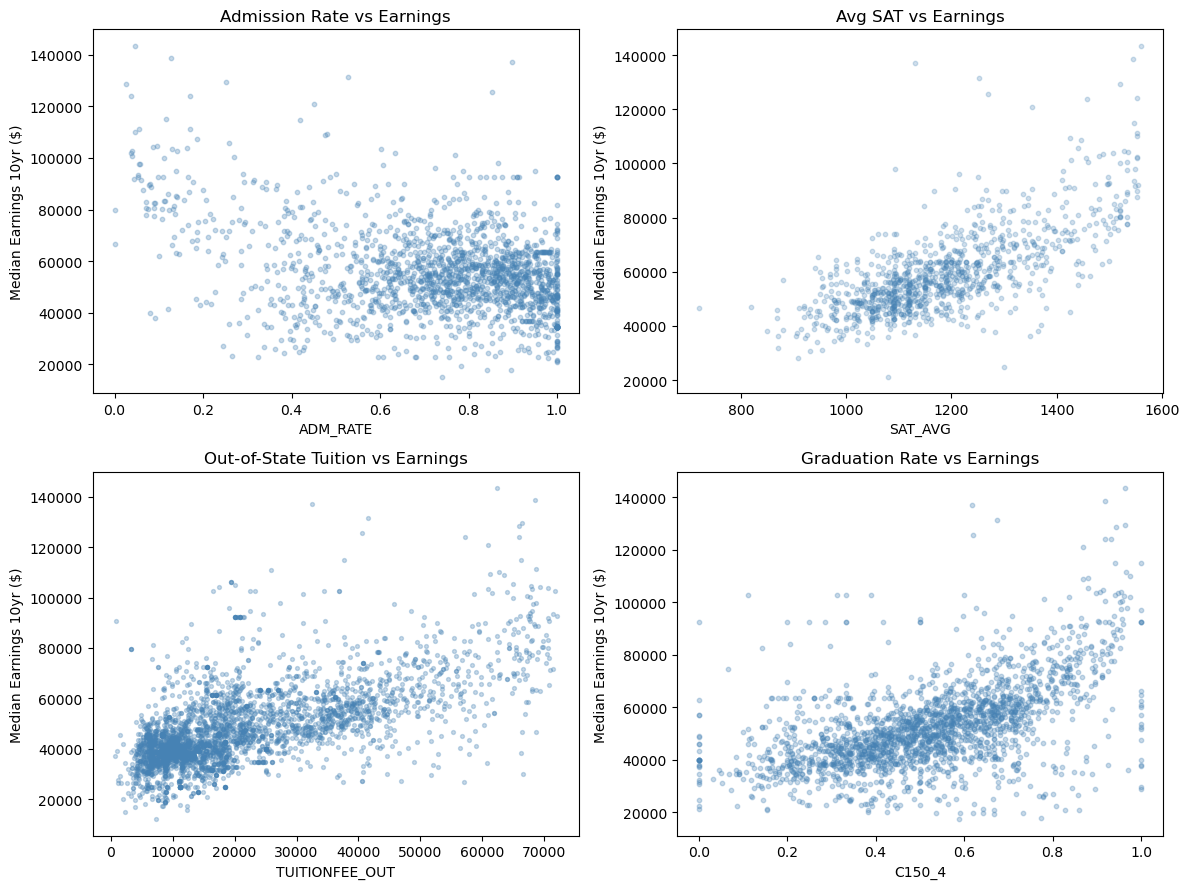

In [9]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 9))

adm_data = df[['ADM_RATE', TARGET]].dropna()
ax1.scatter(adm_data['ADM_RATE'], adm_data[TARGET], alpha=0.3, s=10, color='steelblue')
ax1.set_xlabel('ADM_RATE')
ax1.set_ylabel('Median Earnings 10yr ($)')
ax1.set_title('Admission Rate vs Earnings')

sat_data = df[['SAT_AVG', TARGET]].dropna()
ax2.scatter(sat_data['SAT_AVG'], sat_data[TARGET], alpha=0.25, s=10, color='steelblue')
ax2.set_xlabel('SAT_AVG')
ax2.set_ylabel('Median Earnings 10yr ($)')
ax2.set_title('Avg SAT vs Earnings')

tuit_data = df[['TUITIONFEE_OUT', TARGET]].dropna()
ax3.scatter(tuit_data['TUITIONFEE_OUT'], tuit_data[TARGET], alpha=0.3, s=8, color='steelblue')
ax3.set_xlabel('TUITIONFEE_OUT')
ax3.set_ylabel('Median Earnings 10yr ($)')
ax3.set_title('Out-of-State Tuition vs Earnings')

grad_data = df[['C150_4', TARGET]].dropna()
ax4.scatter(grad_data['C150_4'], grad_data[TARGET], alpha=0.3, s=10, color='steelblue')
ax4.set_xlabel('C150_4')
ax4.set_ylabel('Median Earnings 10yr ($)')
ax4.set_title('Graduation Rate vs Earnings')

plt.tight_layout()
plt.savefig('figures/fig_scatter_features_vs_target.png', bbox_inches='tight')
plt.show()


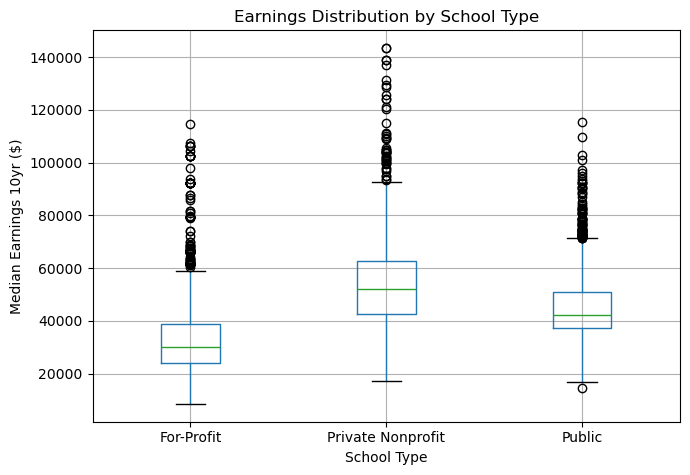

In [10]:
df_ctrl = df[[TARGET, 'CONTROL']].dropna().copy()
df_ctrl['School Type'] = df_ctrl['CONTROL'].map({1.0: 'Public', 2.0: 'Private Nonprofit', 3.0: 'For-Profit'})

fig, ax = plt.subplots(figsize=(7, 5))
df_ctrl.boxplot(column=TARGET, by='School Type', ax=ax)
ax.set_ylabel('Median Earnings 10yr ($)')
ax.set_title('Earnings Distribution by School Type')
plt.suptitle('')
plt.tight_layout()
plt.savefig('figures/fig_earnings_by_school_type.png', bbox_inches='tight')
plt.show()


## 4. Preprocessing

- drop rows where the target is missing (can't impute what we're trying to predict)
- fill missing feature values with the column median
- 80/20 train/test split, random_state=42
- standardize with StandardScaler, needed for ridge/lasso since they penalize coefficient size, so features need to be on the same scale


In [11]:
df_clean = df.dropna(subset=[TARGET]).copy()
print("Rows after dropping missing target: " + str(len(df_clean)))


Rows after dropping missing target: 5173


In [12]:
for col in FEATURES:
    med = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(med)

remaining = df_clean[FEATURES].isnull().sum().sum()
print("Missing values remaining: " + str(remaining))


Missing values remaining: 0


In [13]:
X = df_clean[FEATURES].values
y = df_clean[TARGET].values
institution_names = df_clean['INSTNM'].values

X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X, y, institution_names, test_size=0.2, random_state=42
)

print("Training set: " + str(X_train.shape[0]) + " schools")
print("Test set: " + str(X_test.shape[0]) + " schools")


Training set: 4138 schools
Test set: 1035 schools


In [14]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


## 5. Baseline Models

All from class:

- Linear regression (OLS): no penalty, minimizes squared error directly
- Ridge: L2 penalty, shrinks coefficients toward zero but never all the way
- Lasso: L1 penalty, can zero out coefficients completely (does feature selection)

Used RidgeCV and LassoCV to pick regularization strength via 5-fold cross validation.


In [15]:
alphas = np.logspace(-3, 5, 100)

ols = LinearRegression()
ols.fit(X_train_sc, y_train)


LinearRegression()

In [16]:
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_sc, y_train)
print("Ridge best alpha: " + str(round(ridge.alpha_, 4)))


Ridge best alpha: 27.8256


In [17]:
lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso.fit(X_train_sc, y_train)
print("Lasso best alpha: " + str(round(lasso.alpha_, 4)))


Lasso best alpha: 4.3288


## 6. Evaluation


In [18]:
ols_train_pred = ols.predict(X_train_sc)
ols_test_pred = ols.predict(X_test_sc)

ols_train_rmse = round(np.sqrt(mean_squared_error(y_train, ols_train_pred)), 2)
ols_test_rmse = round(np.sqrt(mean_squared_error(y_test, ols_test_pred)), 2)
ols_mae = round(mean_absolute_error(y_test, ols_test_pred), 2)
ols_r2 = round(r2_score(y_test, ols_test_pred), 2)


In [19]:
ridge_train_pred = ridge.predict(X_train_sc)
ridge_test_pred = ridge.predict(X_test_sc)
ridge_train_rmse = round((mean_squared_error(y_train, ridge_train_pred)) ** 0.5, 2)
ridge_test_rmse = round((mean_squared_error(y_test, ridge_test_pred)) ** 0.5, 2)
ridge_mae = round(mean_absolute_error(y_test, ridge_test_pred), 2)
ridge_r2 = round(r2_score(y_test, ridge_test_pred), 2)


In [20]:
lasso_train_pred = lasso.predict(X_train_sc)
lasso_test_pred = lasso.predict(X_test_sc)
lasso_train_rmse = round((mean_squared_error(y_train, lasso_train_pred)) ** 0.5, 2)
lasso_test_rmse = round((mean_squared_error(y_test, lasso_test_pred)) ** 0.5, 2)
lasso_mae = round(mean_absolute_error(y_test, lasso_test_pred), 2)
lasso_r2 = round(r2_score(y_test, lasso_test_pred), 2)


In [21]:
results_df = pd.DataFrame({
    'Train RMSE': [ols_train_rmse, ridge_train_rmse, lasso_train_rmse],
    'Test RMSE': [ols_test_rmse, ridge_test_rmse, lasso_test_rmse],
    'Test MAE': [ols_mae, ridge_mae, lasso_mae],
    'Test R2': [ols_r2, ridge_r2, lasso_r2]
}, index=['Linear (OLS)', 'Ridge', 'Lasso'])

results_df


,Train RMSE,Test RMSE,Test MAE,Test R2
Linear (OLS),12139.29,11500.01,8208.67,0.47
Ridge,12139.79,11496.07,8199.85,0.47
Lasso,12139.30,11498.99,8207.15,0.47


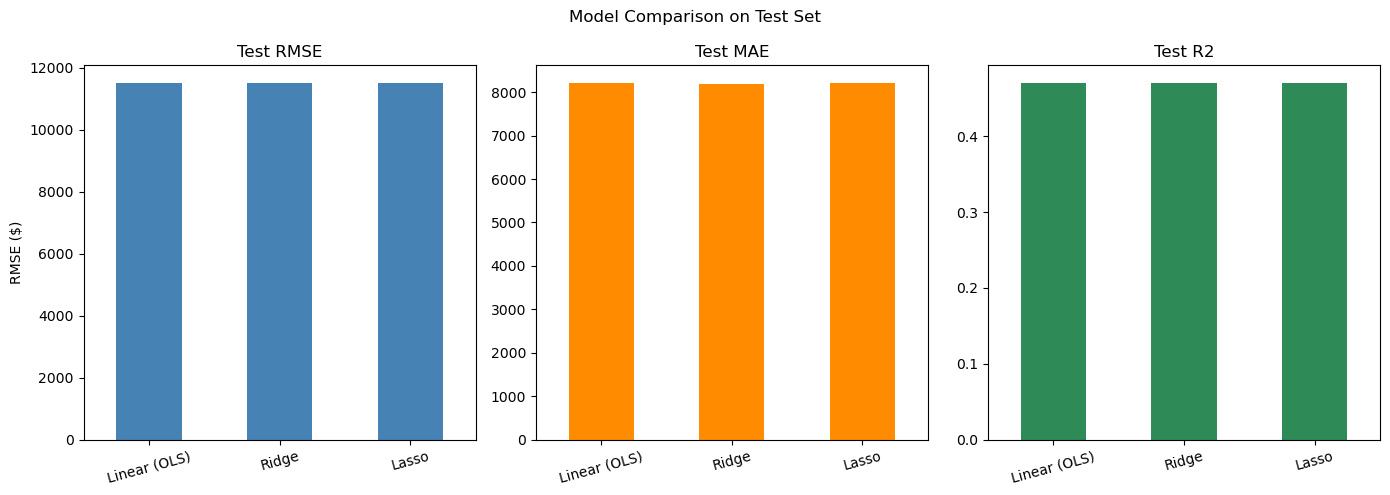

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

results_df[['Test RMSE']].plot(kind='bar', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Test RMSE')
axes[0].set_ylabel('RMSE ($)')
axes[0].tick_params(axis='x', rotation=15)

results_df[['Test MAE']].plot(kind='bar', ax=axes[1], color='darkorange', legend=False)
axes[1].set_title('Test MAE')
axes[1].tick_params(axis='x', rotation=15)

results_df[['Test R2']].plot(kind='bar', ax=axes[2], color='seagreen', legend=False)
axes[2].set_title('Test R2')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison on Test Set')
plt.tight_layout()
plt.savefig('figures/fig_model_comparison.png', bbox_inches='tight')
plt.show()


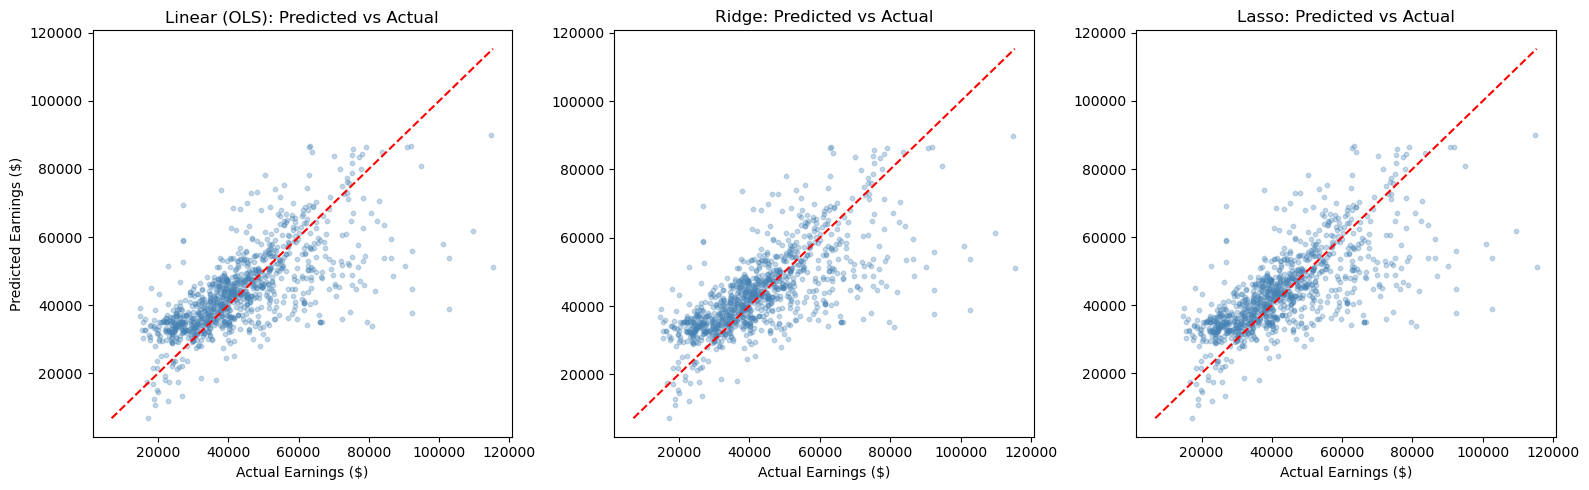

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

lims = [min(y_test.min(), ols_test_pred.min()), max(y_test.max(), ols_test_pred.max())]
axes[0].scatter(y_test, ols_test_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual Earnings ($)')
axes[0].set_ylabel('Predicted Earnings ($)')
axes[0].set_title('Linear (OLS): Predicted vs Actual')

lims = [min(y_test.min(), ridge_test_pred.min()), max(y_test.max(), ridge_test_pred.max())]
axes[1].scatter(y_test, ridge_test_pred, alpha=0.3, s=10, color='steelblue')
axes[1].plot(lims, lims, 'r--', lw=1.5)
axes[1].set_xlabel('Actual Earnings ($)')
axes[1].set_title('Ridge: Predicted vs Actual')

lims = [min(y_test.min(), lasso_test_pred.min()), max(y_test.max(), lasso_test_pred.max())]
axes[2].scatter(y_test, lasso_test_pred, alpha=0.3, s=10, color='steelblue')
axes[2].plot(lims, lims, 'r--', lw=1.5)
axes[2].set_xlabel('Actual Earnings ($)')
axes[2].set_title('Lasso: Predicted vs Actual')

plt.tight_layout()
plt.savefig('figures/fig_predicted_vs_actual.png', bbox_inches='tight')
plt.show()


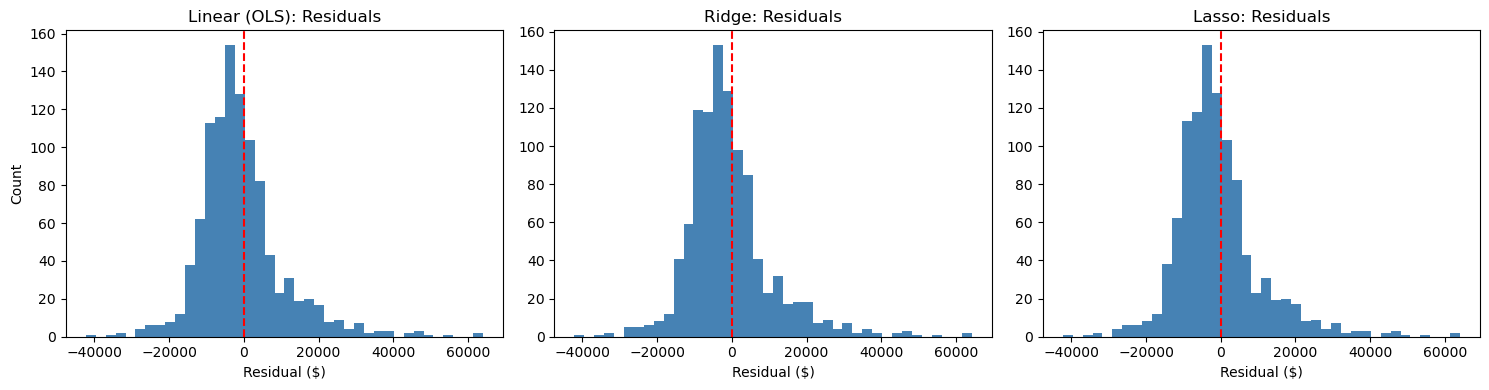

In [24]:
ols_residuals = y_test - ols_test_pred
ridge_residuals = y_test - ridge_test_pred
lasso_residuals = y_test - lasso_test_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pd.Series(ols_residuals).plot(kind='hist', bins=40, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Residual ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Linear (OLS): Residuals')

axes[1].hist(ridge_residuals, bins=40, color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual ($)')
axes[1].set_title('Ridge: Residuals')

axes[2].hist(lasso_residuals, bins=40, color='steelblue')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('Residual ($)')
axes[2].set_title('Lasso: Residuals')

plt.tight_layout()
plt.savefig('figures/fig_residuals.png', bbox_inches='tight')
plt.show()


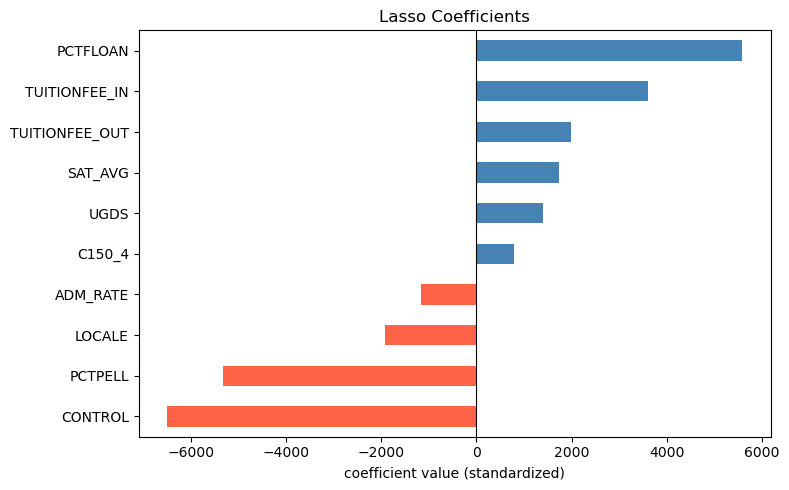

Features zeroed by Lasso: []


In [25]:
lasso_coefs = pd.Series(lasso.coef_, index=FEATURES)
lasso_coefs = lasso_coefs.sort_values()

bar_colors = []
for c in lasso_coefs:
    if c < 0:
        bar_colors.append('tomato')
    else:
        bar_colors.append('steelblue')

fig, ax = plt.subplots(figsize=(8, 5))
lasso_coefs.plot(kind='barh', ax=ax, color=bar_colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('coefficient value (standardized)')
ax.set_title('Lasso Coefficients')
plt.tight_layout()
plt.savefig('figures/fig_lasso_coefficients.png', bbox_inches='tight')
plt.show()

zeroed = lasso_coefs[lasso_coefs == 0].index.tolist()
print("Features zeroed by Lasso: " + str(zeroed))


In [26]:
coef_df = pd.DataFrame({
    'OLS': ols.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
}, index=FEATURES)
print("Model coefficients (standardized scale):")
coef_df.round(3)


Model coefficients (standardized scale):


,OLS,Ridge,Lasso
ADM_RATE,-1171.064,-1163.460,-1167.642
SAT_AVG,1729.517,1704.640,1726.238
TUITIONFEE_IN,3599.757,3457.035,3595.322
TUITIONFEE_OUT,1984.516,2154.366,1992.713
UGDS,1404.976,1400.957,1403.061
C150_4,791.158,792.635,789.249
PCTPELL,-5322.357,-5266.044,-5316.456
PCTFLOAN,5587.594,5474.287,5574.610
CONTROL,-6502.578,-6402.497,-6492.554
LOCALE,-1935.034,-1899.942,-1929.271


## 7. Error Analysis

Looking at where ridge is messing up the most, schools where absolute residual is more than 2x the RMSE.


In [27]:
best_model_name = results_df['Test R2'].idxmax()
print("Best model by R2: " + best_model_name)

if best_model_name == 'Ridge':
    best_preds = ridge_test_pred
elif best_model_name == 'Lasso':
    best_preds = lasso_test_pred
else:
    best_preds = ols_test_pred

best_residuals = y_test - best_preds
best_rmse = np.sqrt(mean_squared_error(y_test, best_preds))


Best model by R2: Linear (OLS)


In [28]:
error_df = pd.DataFrame({
    'Institution': names_test,
    'Actual': y_test,
    'Predicted': best_preds,
    'Residual': best_residuals,
    'Abs Residual': np.abs(best_residuals)
})

threshold = 2 * best_rmse
high_error = error_df[error_df['Abs Residual'] > threshold]
high_error = high_error.sort_values('Abs Residual', ascending=False)

print("Schools with |residual| > 2x RMSE ($" + str(round(threshold)) + "): " + str(len(high_error)))
high_error.head(15)


Schools with |residual| > 2x RMSE ($23000): 59


,Institution,Actual,Predicted,Residual,Abs Residual
957,Los Angeles County College of Nursing and Alli...,115318.0,51224.505801,64093.494199,64093.494199
195,West Coast University-Texas,102672.0,38879.721257,63792.278743,63792.278743
39,Chamberlain University-Indiana,92405.0,37658.235821,54746.764179,54746.764179
1029,West Coast University-Los Angeles,102672.0,53889.062394,48782.937606,48782.937606
310,SUNY Downstate Health Sciences University,109601.0,61773.401516,47827.598484,47827.598484
599,Chamberlain University-Illinois,92405.0,44822.122784,47582.877216,47582.877216
542,United States University,80980.0,33884.377038,47095.622962,47095.622962
457,Unitek College - Reno,79550.0,35082.944756,44467.055244,44467.055244
750,Oregon Health & Science University,101028.0,57962.715997,43065.284003,43065.284003
615,American Musical and Dramatic Academy,26975.0,69298.459197,-42323.459197,42323.459197


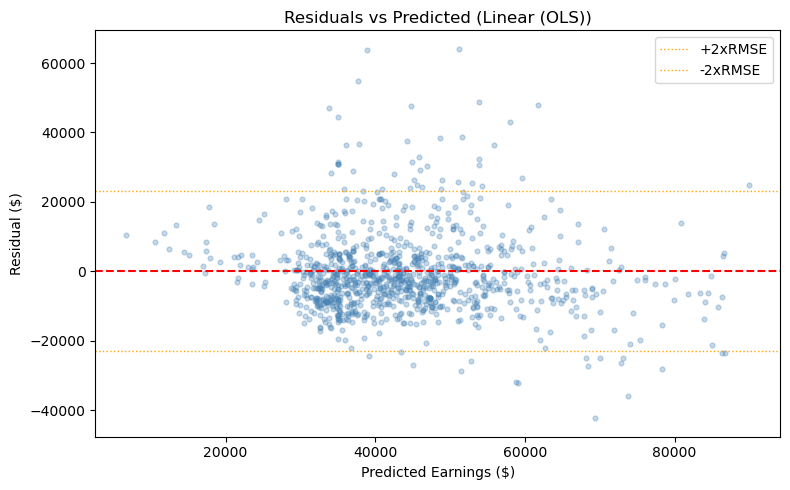

In [29]:
threshold = 2 * best_rmse

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(best_preds, best_residuals, alpha=0.3, s=12, color='steelblue')
ax.axhline(0, color='red', lw=1.5, linestyle='--')
ax.axhline(threshold, color='orange', lw=1, linestyle=':', label='+2xRMSE')
ax.axhline(-threshold, color='orange', lw=1, linestyle=':', label='-2xRMSE')
ax.set_xlabel('Predicted Earnings ($)')
ax.set_ylabel('Residual ($)')
ax.set_title('Residuals vs Predicted (' + best_model_name + ')')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_residuals_vs_predicted.png', bbox_inches='tight')
plt.show()


In [30]:
school_types = df_clean[['INSTNM', 'CONTROL']].drop_duplicates('INSTNM')
df2 = error_df.merge(school_types, left_on='Institution', right_on='INSTNM', how='left')
df2['School Type'] = df2['CONTROL'].map({1.0: 'Public', 2.0: 'Private Nonprofit', 3.0: 'For-Profit'})

public_err = df2[df2['School Type'] == 'Public']['Residual']
private_err = df2[df2['School Type'] == 'Private Nonprofit']['Residual']
fp_err = df2[df2['School Type'] == 'For-Profit']['Residual']

public_rmse = (public_err ** 2).mean() ** 0.5
private_rmse = (private_err ** 2).mean() ** 0.5
fp_rmse = (fp_err ** 2).mean() ** 0.5

print("Public RMSE: " + str(round(public_rmse, 2)))
print("Private Nonprofit RMSE: " + str(round(private_rmse, 2)))
print("For-Profit RMSE: " + str(round(fp_rmse, 2)))


Public RMSE: 9665.51
Private Nonprofit RMSE: 12824.22
For-Profit RMSE: 12283.72


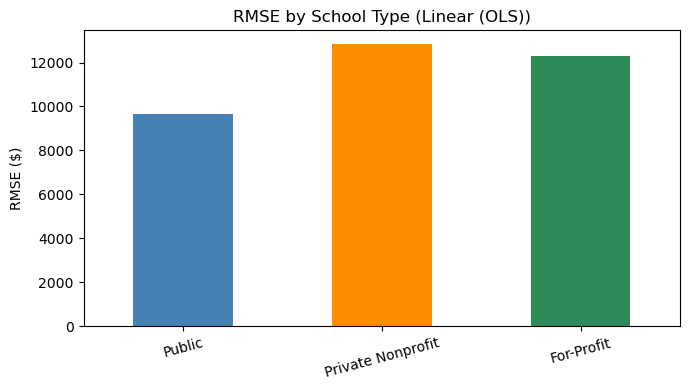

In [31]:
rmse_vals = pd.Series({'Public': public_rmse, 'Private Nonprofit': private_rmse, 'For-Profit': fp_rmse})

fig, ax = plt.subplots(figsize=(7, 4))
rmse_vals.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange', 'seagreen'])
ax.set_ylabel('RMSE ($)')
ax.set_title('RMSE by School Type (' + best_model_name + ')')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
plt.tight_layout()
plt.savefig('figures/fig_rmse_by_school_type.png', bbox_inches='tight')
plt.show()


## 8. Summary


In [32]:
print("Final Model Comparison")
print(results_df.round(2).to_string())
print("")
print("Best model: " + best_model_name + " (R2 = " + str(results_df.loc[best_model_name, 'Test R2']) + ")")


Final Model Comparison
              Train RMSE  Test RMSE  Test MAE  Test R2
Linear (OLS)    12139.29   11500.01   8208.67     0.47
Ridge           12139.79   11496.07   8199.85     0.47
Lasso           12139.30   11498.99   8207.15     0.47

Best model: Linear (OLS) (R2 = 0.47)


### results

- Linear OLS: train RMSE $12,139 / test RMSE $11,500 / MAE $8,209 / R2 0.47
- Ridge (alpha=27.83): train RMSE $12,140 / test RMSE $11,496 / MAE $8,200 / R2 0.47
- Lasso (alpha=4.33): train RMSE $12,139 / test RMSE $11,499 / MAE $8,207 / R2 0.47

All three came out basically the same. Ridge is technically best but barely. Regularization didn't really help which probably means the features aren't highly correlated with each other. Lasso also didn't zero out any features so all 10 contributed something.

R2 of 0.47 means we explain about half the variance in earnings. The biggest coefficients were CONTROL (school type), PCTFLOAN, and PCTPELL. Makes sense, for-profit schools tend to have lower outcomes and schools with more low-income students tend to have lower median earnings.

Biggest errors were almost all nursing/health sciences schools, they earn a lot more than general institutions but our features don't capture that at all. Public schools had the lowest error by type ($9,664 RMSE) and private nonprofit was the highest ($12,797).

### next steps

- log transform the target, residuals get bigger at higher earnings so this might help
- add features about what programs the school actually offers
- try SVM or MLP for the final project
- also want to try predicting median debt as the target instead
